# Exploratory Data Analysis: UK Fruit & Vegetable Price Prediction

## Goal
Predict wholesale prices of fruits and vegetables in the UK using a combination of:
- **Weekly wholesale fruit & vegetable prices** (DEFRA)
- **Agricultural Price Indices** (DEFRA)
- **Fertiliser prices** (AHDB)
- **Road fuel prices** (BEIS)
- **Road freight transport cost index** (ONS SPPI)
- **Consumer Price Inflation tables** (ONS)

## Data Sources
| File | Source | Content | Frequency |
|------|--------|---------|-----------|
| `fruitveg-weeklyhort-260216.ods` | DEFRA | Wholesale fruit/veg prices | Weekly, 2015-2026 |
| `API_20260129.csv` | DEFRA | Agricultural price indices | Monthly, 2014-2025 |
| `GBFertiliserPriceSeries.xlsx` | AHDB | Fertiliser spot prices | Monthly, 2017-2026 |
| `weekly_road_fuel_prices_*.csv` | BEIS | Petrol & diesel prices | Weekly, 2003-2026 |
| `series-210226.csv` | ONS | Road freight SPPI | Quarterly/Annual, 1996-2025 |
| `consumerpriceinflation*.xlsx` | ONS | CPI/CPIH/RPI tables | Monthly, 1988-2026 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

DATA = 'data/'

---
## 1. Wholesale Fruit & Vegetable Prices (Target Variable)

This is the **primary dataset** -- weekly wholesale prices for ~72 commodities collected from UK wholesale markets.

In [2]:
# Load all yearly sheets from the ODS file and combine
ods_file = DATA + 'fruitveg-weeklyhort-260216.ods'

all_frames = []

for sheet_name in ['2016-2015', '2017-2016', '2017', '2018', '2019', '2020',
                    '2021', '2022', '2023', '2024', '2025', '2026']:
    try:
        raw = pd.read_excel(ods_file, sheet_name=sheet_name, header=None, engine='odf')
        print(f"Sheet '{sheet_name}': shape = {raw.shape}")
    except Exception as e:
        print(f"Sheet '{sheet_name}': ERROR - {e}")

Sheet '2016-2015': shape = (167, 108)
Sheet '2017-2016': shape = (167, 101)
Sheet '2017': shape = (111, 14)
Sheet '2018': shape = (117, 57)
Sheet '2019': shape = (106, 57)
Sheet '2020': shape = (104, 57)
Sheet '2021': shape = (104, 57)
Sheet '2022': shape = (104, 57)
Sheet '2023': shape = (104, 57)
Sheet '2024': shape = (104, 57)
Sheet '2025': shape = (104, 57)
Sheet '2026': shape = (104, 57)


In [3]:
# Inspect the structure of one sheet
raw_2025 = pd.read_excel(ods_file, sheet_name='2025', header=None, engine='odf')
raw_2025.iloc[:16, :8]

,0,1,2,3,4,5,6,7
0,NaN,National average wholesale prices of home-grow...,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Updated on:,19/01/2026,NaN,NaN,NaN,NaN,NaN
2,NaN,Next update:,02/02/2026,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,,NaN,NaN,NaN,NaN,NaN
4,NaN,Contact:,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Agricultural Accounts and Market Prices team,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,"Department for Environment, Food and Rural Aff...",NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Tel: +44 (0)7920 073612,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
def parse_fruitveg_sheet(ods_file, sheet_name):
    """Parse a single year-sheet from the DEFRA fruit/veg ODS file.
    Returns a long-format DataFrame with columns:
    [date, commodity_type, sub_category, variety, unit, price]
    """
    raw = pd.read_excel(ods_file, sheet_name=sheet_name, header=None, engine='odf')
    
    # Find the row containing 'Commodity' to locate data start
    date_row = None
    data_start = None
    for i in range(min(20, len(raw))):
        row_vals = raw.iloc[i].astype(str)
        if any('commodity' in str(v).lower() for v in row_vals):
            data_start = i + 1
            date_row = i - 2
            break
    
    if date_row is None or data_start is None:
        date_row = 11
        data_start = 14
    
    # Extract week-ending dates from the date row
    dates = []
    date_cols = []
    for col_idx in range(5, raw.shape[1]):
        val = raw.iloc[date_row, col_idx]
        if pd.notna(val):
            try:
                d = pd.to_datetime(val)
                dates.append(d)
                date_cols.append(col_idx)
            except:
                pass
    
    if not dates:
        return pd.DataFrame()
    
    records = []
    for row_idx in range(data_start, raw.shape[0]):
        row = raw.iloc[row_idx]
        commodity_type = row.iloc[1] if pd.notna(row.iloc[1]) else None
        sub_category = row.iloc[2] if pd.notna(row.iloc[2]) else None
        variety = row.iloc[3] if pd.notna(row.iloc[3]) else None
        unit = row.iloc[4] if pd.notna(row.iloc[4]) else None
        
        if commodity_type is None and sub_category is None and variety is None:
            continue
        
        for date, col_idx in zip(dates, date_cols):
            price = row.iloc[col_idx]
            if pd.notna(price):
                try:
                    price = float(price)
                    records.append({
                        'date': date,
                        'commodity_type': commodity_type,
                        'sub_category': sub_category,
                        'variety': variety,
                        'unit': unit,
                        'price': price
                    })
                except (ValueError, TypeError):
                    pass
    
    return pd.DataFrame(records)


# Parse all sheets
frames = []
for sheet_name in ['2016-2015', '2017-2016', '2017', '2018', '2019', '2020',
                    '2021', '2022', '2023', '2024', '2025', '2026']:
    df = parse_fruitveg_sheet(ods_file, sheet_name)
    if not df.empty:
        print(f"Sheet '{sheet_name}': {len(df)} records, dates {df['date'].min().date()} to {df['date'].max().date()}")
        frames.append(df)

fv = pd.concat(frames, ignore_index=True)

# Forward-fill commodity_type since it's only listed once per group
fv['commodity_type'] = fv['commodity_type'].ffill()
fv['sub_category'] = fv['sub_category'].ffill()

# De-duplicate in case overlapping sheets
fv = fv.drop_duplicates(subset=['date', 'commodity_type', 'sub_category', 'variety'])
fv = fv.sort_values('date').reset_index(drop=True)

print(f"\nCombined dataset: {fv.shape}")
print(f"Date range: {fv['date'].min().date()} to {fv['date'].max().date()}")
fv.head(10)

Sheet '2016-2015': 6743 records, dates 2015-01-09 to 2016-12-16
Sheet '2017-2016': 5994 records, dates 2016-01-08 to 2017-10-27
Sheet '2017': 375 records, dates 2017-11-03 to 2017-12-22
Sheet '2018': 2359 records, dates 2018-01-12 to 2018-12-21
Sheet '2019': 2271 records, dates 2019-01-11 to 2019-12-20
Sheet '2020': 2165 records, dates 2020-01-10 to 2020-12-18
Sheet '2021': 2162 records, dates 2021-01-08 to 2021-12-17
Sheet '2022': 2156 records, dates 2022-01-07 to 2022-12-23
Sheet '2023': 2107 records, dates 2023-01-13 to 2023-12-15
Sheet '2024': 2168 records, dates 2024-01-12 to 2024-12-20
Sheet '2025': 1117 records, dates 2025-01-20 to 2025-12-22
Sheet '2026': 89 records, dates 2026-01-19 to 2026-02-16

Combined dataset: (26448, 6)
Date range: 2015-01-09 to 2026-02-16


,date,commodity_type,sub_category,variety,unit,price
0,2015-01-09,Dessert Apples,Gala,1st,£/kg,0.616986
1,2015-01-09,Cabbage,Summer & Autumn Round,-,£/head,0.350000
2,2015-01-09,Swede,All Varieties,-,£/kg,0.303064
3,2015-01-09,Leeks (d),Trimmed,-,£/kg,0.784000
4,2015-01-09,Chrysanthemums Flowers,Indoor spray,-,£/spray,0.235000
5,2015-01-09,Dessert Apples,Jonogold group,1st,£/kg,0.595248
6,2015-01-09,Dessert Apples,Jonogold group,Ave,£/kg,0.595248
7,2015-01-09,Dessert Apples,Braeburn,2nd,£/kg,0.462971
8,2015-01-09,Lettuce,Butterhead Indoor,1st,£/head,0.333304
9,2015-01-09,Dessert Apples,Egremont Russet,Ave,£/kg,0.728783


In [5]:
# Basic statistics
print("Commodity types:")
print(fv['commodity_type'].value_counts())
print(f"\nUnique sub-categories: {fv['sub_category'].nunique()}")
print(f"Unique varieties: {fv['variety'].nunique()}")
print(f"\nPrice statistics:")
fv['price'].describe()

Commodity types:
commodity_type
Vegetable                        12900
Fruit                             3596
Dessert Apples                    1387
Lettuce                           1137
Cabbage                            863
Tomatoes                           825
Pears                              695
Cooking Apples                     426
Cut flowers                        424
Strawberries                       289
Bulb Onions                        284
Cauliflowers                       266
Capsicums                          241
Rhubarb                            146
Parsnips                           142
Swede                              142
Alstromeria                        142
Watercress                         142
Beetroot (d)                       142
Leeks (d)                          140
Carrots                            139
Turnip                             138
Cucumbers                          113
Oriental Lilies                    104
Spinach leaf                    

count    26448.000000
mean         1.454053
std          1.909379
min          0.000000
25%          0.530838
50%          0.830000
75%          1.390000
max         20.140000
Name: price, dtype: float64

In [6]:
# Show all unique commodity items
items = fv.groupby(['commodity_type', 'sub_category', 'variety']).agg(
    n_weeks=('date', 'count'),
    avg_price=('price', 'mean'),
    min_price=('price', 'min'),
    max_price=('price', 'max'),
    first_date=('date', 'min'),
    last_date=('date', 'max')
).reset_index()
items = items.sort_values(['commodity_type', 'sub_category', 'variety'])
print(f"Total unique items: {len(items)}")
items

Total unique items: 204


,commodity_type,sub_category,variety,n_weeks,avg_price,min_price,max_price,first_date,last_date
0,Alstromeria,Indoor,-,142,1.273057,0.988125,1.540000,2015-01-09,2017-10-27
1,Asparagus,All Varieties,-,54,8.469500,4.894937,15.660000,2015-03-27,2017-07-14
2,Beetroot (d),Topped,-,142,0.366390,0.325401,0.440268,2015-01-09,2017-10-27
3,Begonia elatior,13 cm,-,45,1.099688,0.330000,1.500000,2015-01-09,2017-08-04
4,Blackcurrants,All Varieties,-,25,5.769449,3.560000,9.840000,2015-07-03,2017-08-18
...,...,...,...,...,...,...,...,...,...
199,Vegetable,Tomatoes,Vine,242,1.502445,0.650000,4.450000,2017-11-03,2025-12-22
200,Vegetable,Watercress,Pillow packs,50,9.516400,6.840000,12.680000,2018-01-12,2018-12-21
201,Vegetable,Watercress (d),Pillow packs,34,8.899118,6.550000,10.160000,2019-01-11,2019-08-30
202,Vegetable,Watercress (f),Pillow packs,8,10.506250,8.040000,11.440000,2017-11-03,2017-12-22


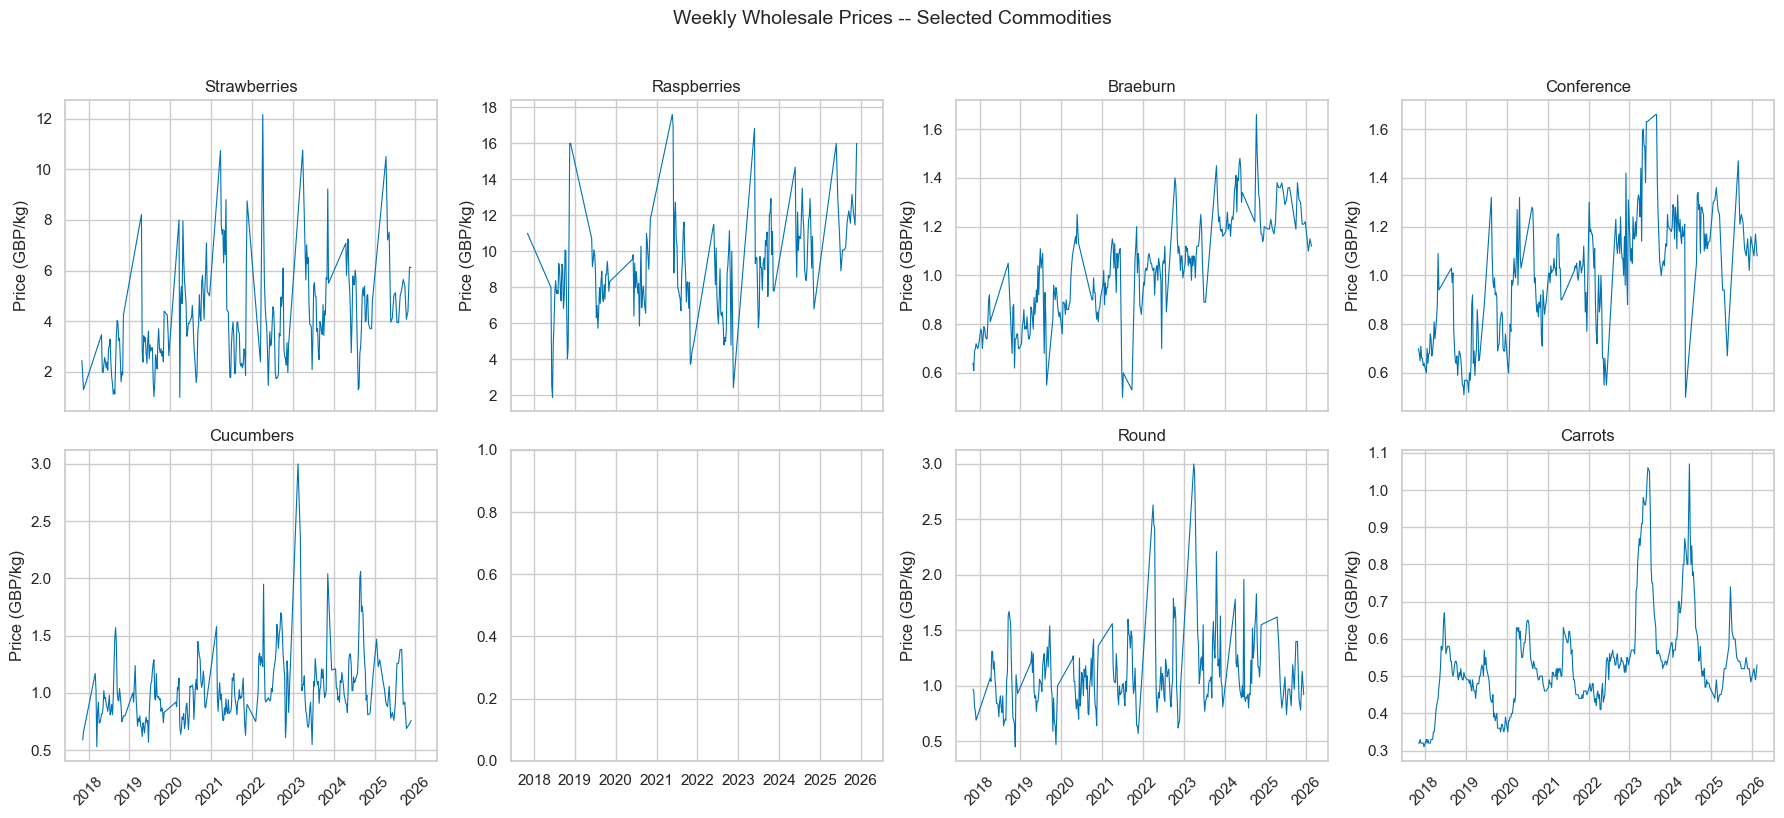

In [7]:
# Plot price trends for selected popular commodities
popular = ['Strawberries', 'Raspberries', 'Braeburn', 'Conference',
           'Cucumbers', 'Iceberg', 'Round', 'Carrots']

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)
axes = axes.flatten()

for i, variety in enumerate(popular):
    subset = fv[fv['variety'] == variety].sort_values('date')
    if subset.empty:
        subset = fv[fv['sub_category'] == variety].sort_values('date')
    if not subset.empty:
        axes[i].plot(subset['date'], subset['price'], linewidth=0.8)
        axes[i].set_title(variety)
        axes[i].set_ylabel('Price (GBP/kg)')
        axes[i].tick_params(axis='x', rotation=45)

fig.suptitle('Weekly Wholesale Prices -- Selected Commodities', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

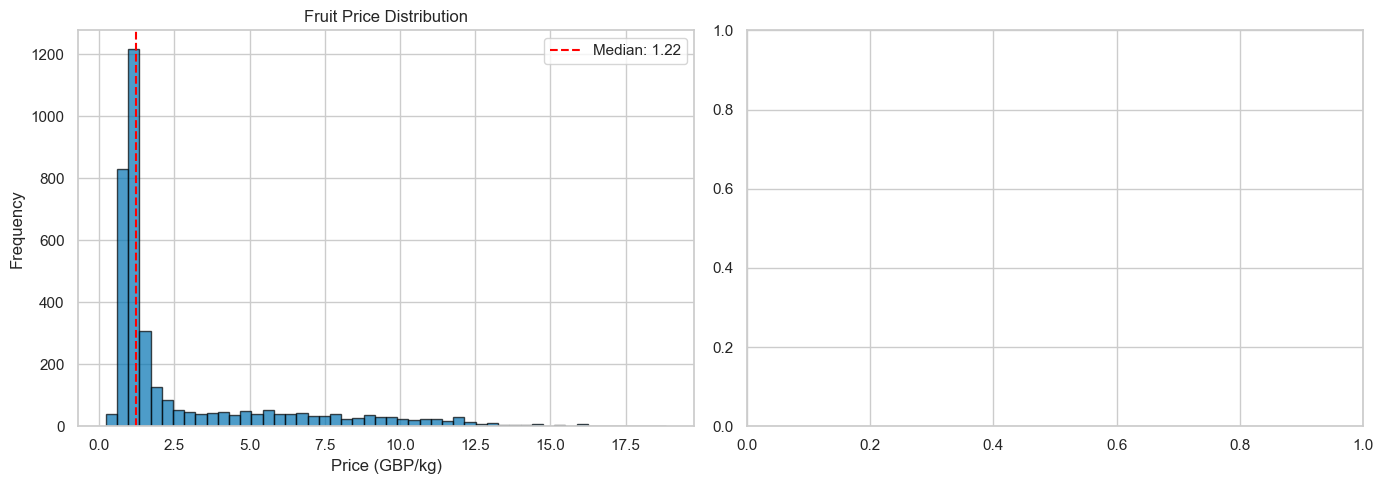

In [8]:
# Distribution of prices by commodity type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, ctype in enumerate(['Fruit', 'Vegetables']):
    subset = fv[fv['commodity_type'].str.contains(ctype, case=False, na=False)]
    if not subset.empty:
        axes[i].hist(subset['price'], bins=50, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{ctype} Price Distribution')
        axes[i].set_xlabel('Price (GBP/kg)')
        axes[i].set_ylabel('Frequency')
        axes[i].axvline(subset['price'].median(), color='red', linestyle='--',
                        label=f'Median: {subset["price"].median():.2f}')
        axes[i].legend()

plt.tight_layout()
plt.show()

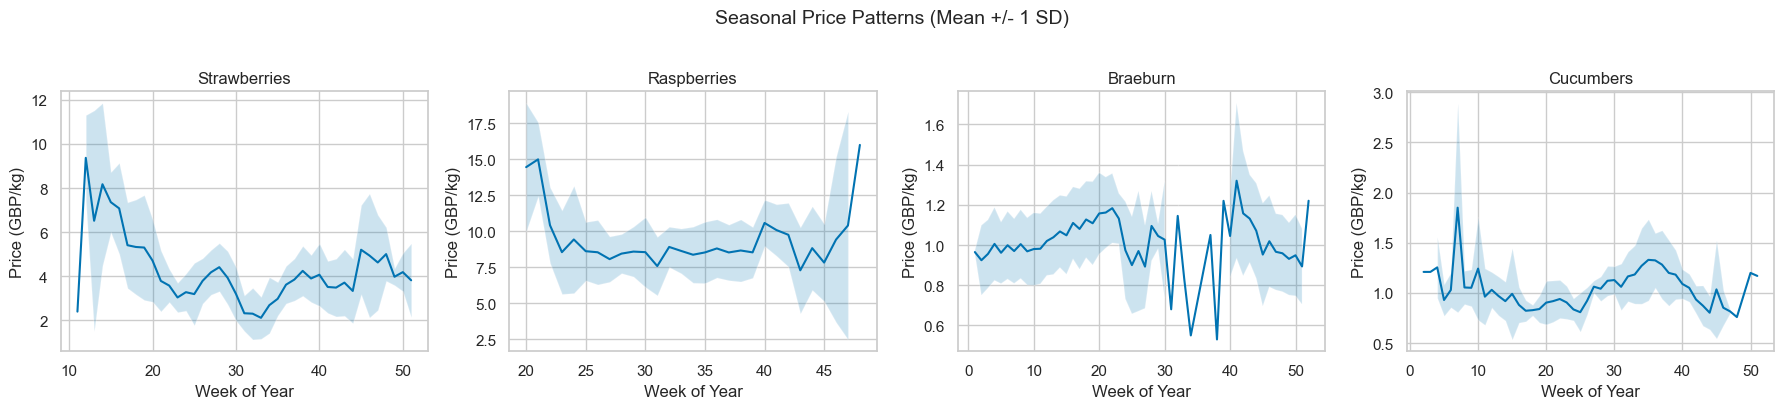

In [9]:
# Seasonality analysis: average price by week of year for selected items
fv['week'] = fv['date'].dt.isocalendar().week.astype(int)

seasonal_items = ['Strawberries', 'Raspberries', 'Braeburn', 'Cucumbers']
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

for i, variety in enumerate(seasonal_items):
    subset = fv[fv['variety'] == variety]
    if subset.empty:
        subset = fv[fv['sub_category'] == variety]
    if not subset.empty:
        weekly_avg = subset.groupby('week')['price'].agg(['mean', 'std']).reset_index()
        axes[i].plot(weekly_avg['week'], weekly_avg['mean'], linewidth=1.5)
        axes[i].fill_between(weekly_avg['week'],
                             weekly_avg['mean'] - weekly_avg['std'],
                             weekly_avg['mean'] + weekly_avg['std'], alpha=0.2)
        axes[i].set_title(variety)
        axes[i].set_xlabel('Week of Year')
        axes[i].set_ylabel('Price (GBP/kg)')

fig.suptitle('Seasonal Price Patterns (Mean +/- 1 SD)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

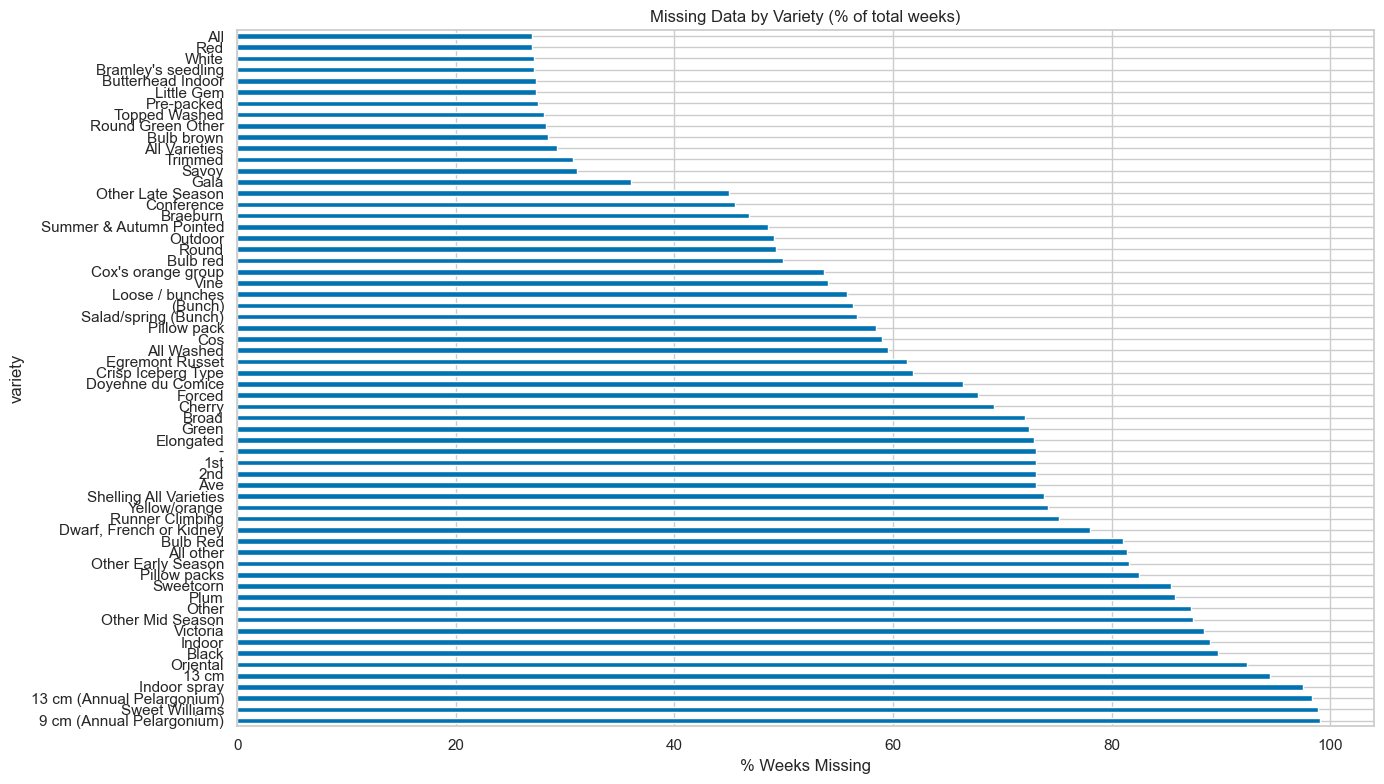


Varieties with >50% missing: 41
Varieties with <10% missing: 0


In [10]:
# Missing data analysis
pivot = fv.pivot_table(index='date', columns='variety', values='price', aggfunc='first')
missing_pct = pivot.isnull().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(14, 8))
missing_pct.plot(kind='barh', ax=ax)
ax.set_xlabel('% Weeks Missing')
ax.set_title('Missing Data by Variety (% of total weeks)')
plt.tight_layout()
plt.show()

print(f"\nVarieties with >50% missing: {(missing_pct > 50).sum()}")
print(f"Varieties with <10% missing: {(missing_pct < 10).sum()}")

---
## 2. Agricultural Price Index (API)

In [11]:
api = pd.read_csv(DATA + 'API_20260129.csv')
api['date'] = pd.to_datetime(api['date'])

print(f"Shape: {api.shape}")
print(f"Date range: {api['date'].min().date()} to {api['date'].max().date()}")
print(f"Types: {api['type'].unique()}")
print(f"\nNumber of categories: {api['category'].nunique()}")
print(f"\nNull values:\n{api.isnull().sum()}")
api.head()

Shape: (14981, 4)
Date range: 2014-01-01 to 2025-11-01
Types: ['output' 'input']

Number of categories: 106

Null values:
type        0
category    0
date        0
index       0
dtype: int64


,type,category,date,index
0,output,crop_products,2025-11-01,118.383104
1,output,cereals,2025-11-01,106.775294
2,output,wheat,2025-11-01,103.704124
3,output,wheat_breadmaking,2025-11-01,100.414004
4,output,wheat_other_milling,2025-11-01,104.880762


In [12]:
# List all categories by type
for t in ['output', 'input']:
    cats = api[api['type'] == t]['category'].unique()
    print(f"\n{t.upper()} categories ({len(cats)}):")
    for c in sorted(cats):
        print(f"  - {c}")


OUTPUT categories (57):
  - all_agricultural_outputs
  - all_poultry
  - animal_products
  - animals_and_animal_products
  - animals_for_slaughter_export
  - barley
  - barley_feeding
  - barley_malting
  - beans_green
  - cabbages
  - calves
  - carrots
  - cattle_and_calves
  - cattle_clean
  - cauliflowers
  - cereals
  - chickens
  - cooking_apples
  - cows_and_bulls
  - crop_products
  - dessert_apples
  - dessert_pears
  - eggs
  - ewes_and_rams
  - flowers_and_plants
  - forage_plants
  - free_range_eggs
  - fresh_fruit
  - fresh_vegetables
  - industrial_crops
  - intensive_eggs
  - lettuce
  - milk
  - mushrooms
  - oats
  - oats_feeding
  - oats_milling
  - oilseed_rape
  - onions
  - other_crop_products
  - pigs
  - pigs_clean
  - potatoes
  - raspberries
  - sheep_and_lambs
  - sheep_and_lambs_clean
  - sows_and_boars
  - straw
  - strawberries
  - sugar_beet
  - tomatoes
  - turkeys
  - wheat
  - wheat_breadmaking
  - wheat_feeding
  - wheat_other_milling
  - wool_clip

I

Relevant subset: (1144, 4)


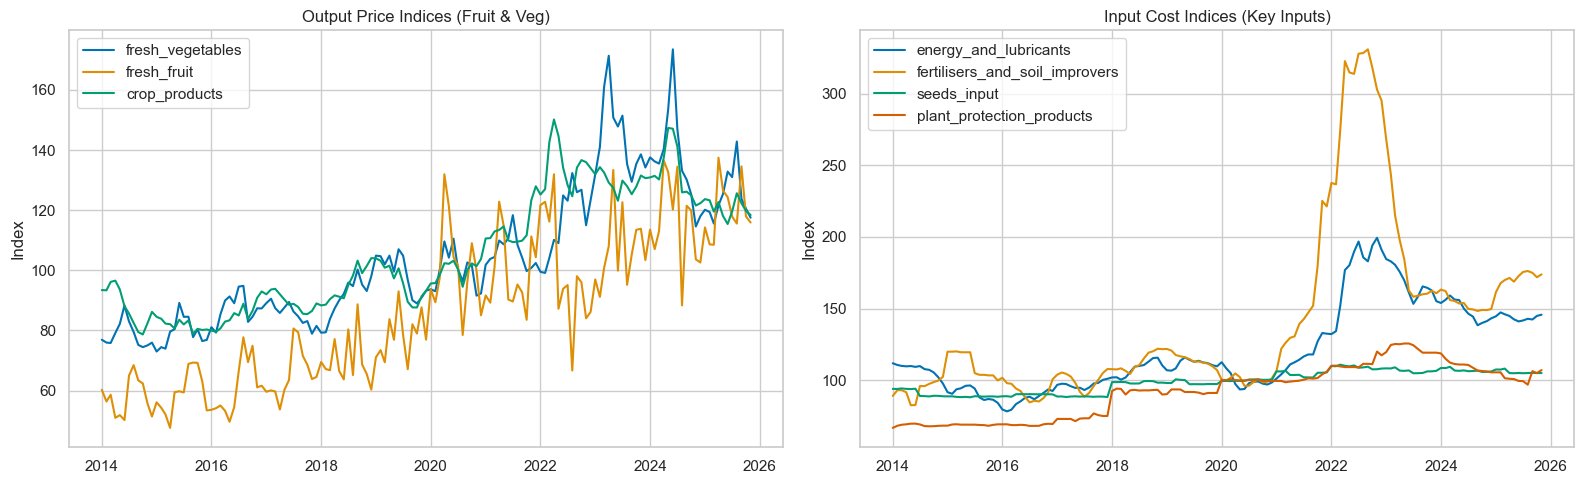

In [13]:
# Focus on categories relevant to fruit & veg prediction
relevant_cats = [
    'fresh_vegetables', 'fresh_fruit',
    'crop_products', 'energy_and_lubricants', 'fertilisers_and_soil_improvers',
    'seeds_input', 'plant_protection_products',
    'all_goods_and_services_currently_consumed_in_agriculture'
]

api_rel = api[api['category'].isin(relevant_cats)].copy()
print(f"Relevant subset: {api_rel.shape}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Output indices
for cat in ['fresh_vegetables', 'fresh_fruit', 'crop_products']:
    subset = api_rel[(api_rel['category'] == cat) & (api_rel['type'] == 'output')]
    if not subset.empty:
        axes[0].plot(subset['date'], subset['index'], label=cat)
axes[0].set_title('Output Price Indices (Fruit & Veg)')
axes[0].set_ylabel('Index')
axes[0].legend()

# Input indices
for cat in ['energy_and_lubricants', 'fertilisers_and_soil_improvers',
            'seeds_input', 'plant_protection_products']:
    subset = api_rel[(api_rel['category'] == cat) & (api_rel['type'] == 'input')]
    if not subset.empty:
        axes[1].plot(subset['date'], subset['index'], label=cat)
axes[1].set_title('Input Cost Indices (Key Inputs)')
axes[1].set_ylabel('Index')
axes[1].legend()

plt.tight_layout()
plt.show()

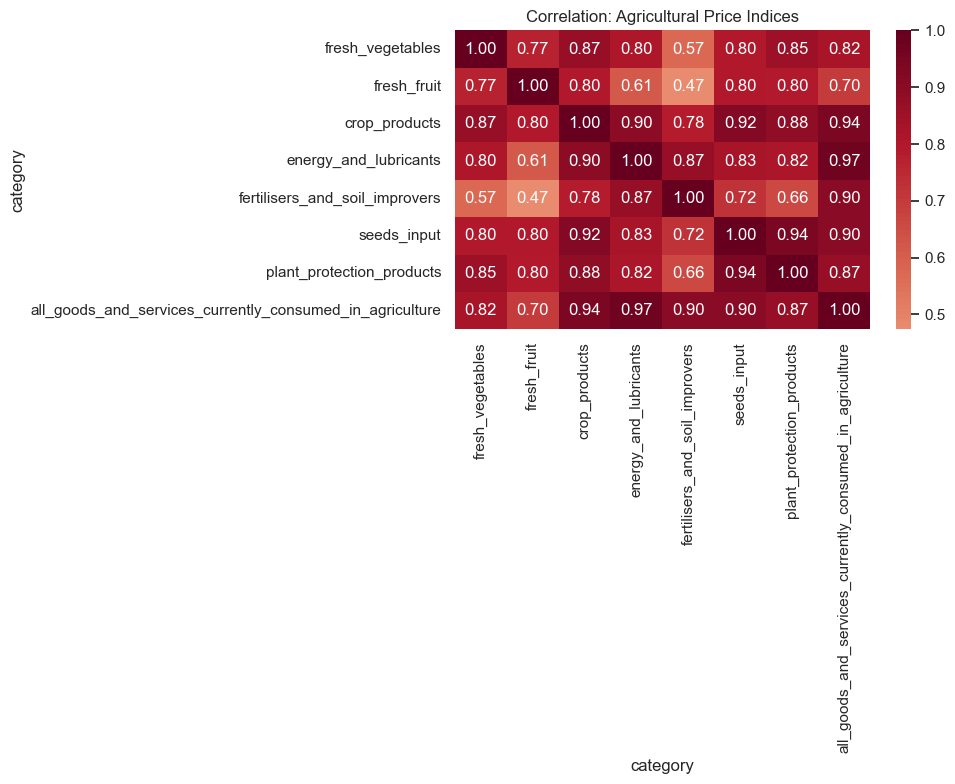

In [14]:
# Correlation between input costs and output prices
api_wide = api.pivot_table(index='date', columns='category', values='index')

corr_cols = [c for c in relevant_cats if c in api_wide.columns]
corr_matrix = api_wide[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlation: Agricultural Price Indices')
plt.tight_layout()
plt.show()

---
## 3. Fertiliser Prices

In [15]:
# Read the main data sheet
fert = pd.read_excel(DATA + 'GBFertiliserPriceSeries.xlsx',
                      sheet_name='GB Fertiliser Price Series ',
                      header=None)
print(f"Raw shape: {fert.shape}")
fert.iloc[:10, :10]

Raw shape: (123, 20)


,0,1,2,3,4,5,6,7,8,9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GB fertiliser prices,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Source: AHDB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Units: £/tonne,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Last updated: 11/02/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Variation indicator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,The arrows in the table below are an indicatio...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,"In January, the UAN price at the end of the mo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,"In January, the TSP price at the end of the mo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Parse the fertiliser price sheet
fert_raw = pd.read_excel(DATA + 'GBFertiliserPriceSeries.xlsx',
                          sheet_name='GB Fertiliser Price Series ',
                          header=None)

# Display rows to understand structure
for i in range(min(15, len(fert_raw))):
    print(f"Row {i}: {fert_raw.iloc[i, :6].tolist()}")

Row 0: [nan, nan, nan, nan, nan, nan]
Row 1: ['GB fertiliser prices', nan, nan, nan, nan, nan]
Row 2: ['Source: AHDB', nan, nan, nan, nan, nan]
Row 3: ['Units: £/tonne', nan, nan, nan, nan, nan]
Row 4: ['Last updated: 11/02/2026', nan, nan, nan, nan, nan]
Row 5: [nan, 'Variation indicator', nan, nan, nan, nan]
Row 6: [nan, 'The arrows in the table below are an indication of the level of variation between the start and end of the month. For example:', nan, nan, nan, nan]
Row 7: [nan, 'In January, the UAN price at the end of the month was 7% higher than at the start of the month which means it has been given a variation indicator of “↗”', nan, nan, nan, nan]
Row 8: [nan, 'In January, the TSP price at the end of the month was 1% higher than at the start of the month which means it has been given a variation indicator of “→”', nan, nan, nan, nan]
Row 9: [nan, nan, nan, nan, nan, nan]
Row 10: [nan, 'Variation indicator key', nan, nan, nan, nan]
Row 11: [nan, '→ Less than \n5% variation', '↗

In [17]:
# Try reading with different skiprows to find the data
for skip in [3, 4, 5, 6, 7, 8]:
    temp = pd.read_excel(DATA + 'GBFertiliserPriceSeries.xlsx',
                          sheet_name='GB Fertiliser Price Series ',
                          skiprows=skip, nrows=3)
    first_col = temp.iloc[:, 0]
    has_dates = False
    for v in first_col[:5]:
        if isinstance(v, (pd.Timestamp,)) or 'jan' in str(v).lower() or '20' in str(v):
            has_dates = True
            break
    print(f"skiprows={skip}: first values = {first_col[:3].tolist()}, has_dates={has_dates}")
    if has_dates:
        print(f"  Columns: {temp.columns.tolist()[:8]}")
        print(temp.head(3))
        break

skiprows=3: first values = ['Last updated: 11/02/2026', nan, nan], has_dates=True
  Columns: ['Units: £/tonne', 'Unnamed: 1']
             Units: £/tonne                                         Unnamed: 1
0  Last updated: 11/02/2026                                                NaN
1                       NaN                                Variation indicator
2                       NaN  The arrows in the table below are an indicatio...


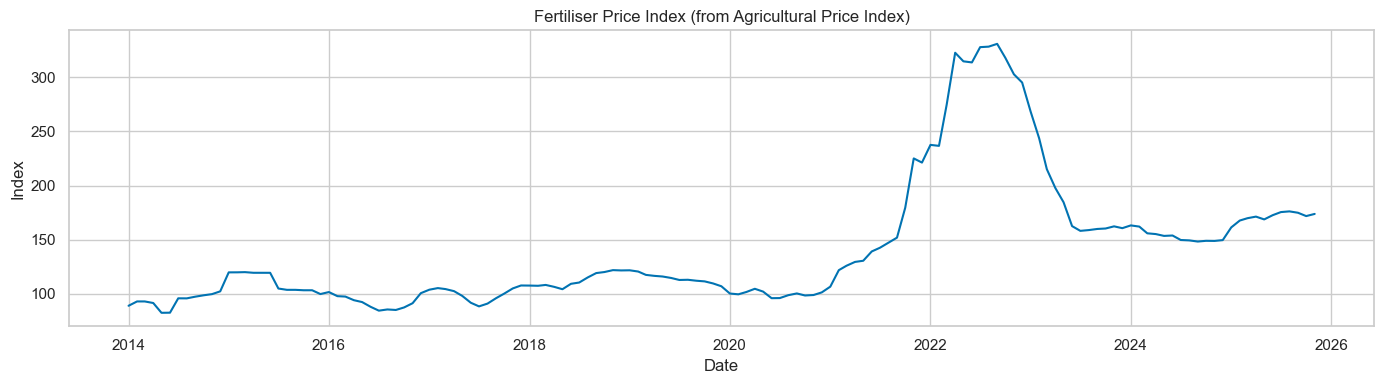

Fertiliser index stats:


count    143.000000
mean     140.369794
std       60.155676
min       82.599690
25%      100.602790
50%      116.698121
75%      160.576807
max      330.884081
Name: index, dtype: float64

In [18]:
# Use the API fertiliser index as primary fertiliser signal
# (cleaner than parsing the complex spreadsheet)
fert_api = api[(api['type'] == 'input') & (api['category'] == 'fertilisers_and_soil_improvers')].copy()
fert_api = fert_api.sort_values('date').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(fert_api['date'], fert_api['index'])
ax.set_title('Fertiliser Price Index (from Agricultural Price Index)')
ax.set_ylabel('Index')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

print(f"Fertiliser index stats:")
fert_api['index'].describe()

---
## 4. Road Fuel Prices

In [19]:
fuel1 = pd.read_csv(DATA + 'weekly_road_fuel_prices_2003_to_2017.csv')
fuel2 = pd.read_csv(DATA + 'weekly_road_fuel_prices_2018_to_now.csv')

print("File 1 columns:")
for c in fuel1.columns:
    print(f"  {c}")
print(f"\nFile 2 columns:")
for c in fuel2.columns:
    print(f"  {c}")

File 1 columns:
  Date
  ULSP (Ultra low sulphur unleaded petrol) Pump price in pence/litre
  ULSD (Ultra low sulphur diesel) Pump price in pence/litre
  ULSP (Ultra low sulphur unleaded petrol) Duty rate in pence/litre
  ULSD (Ultra low sulphur diesel) Duty rate in pence/litre
  ULSP (Ultra low sulphur unleaded petrol) VAT percentage rate
  ULSD (Ultra low sulphur diesel) VAT percentage rate

File 2 columns:
  Date
  ULSP (Ultra low sulphur unleaded petrol) Pump price in pence/litre
  ULSD (Ultra low sulphur diesel) Pump price in pence/litre
  ULSP (Ultra low sulphur unleaded petrol) Duty rate in pence/litre
  ULSD (Ultra low sulphur diesel) Duty rate in pence/litre
  ULSP (Ultra low sulphur unleaded petrol) VAT percentage rate
  ULSD (Ultra low sulphur diesel) VAT percentage rate


In [20]:
# Combine fuel datasets
fuel = pd.concat([fuel1, fuel2], ignore_index=True)

col_map = {}
for c in fuel.columns:
    cl = c.lower()
    if 'date' in cl:
        col_map[c] = 'date'
    elif 'ulsp' in cl and 'pump' in cl:
        col_map[c] = 'petrol_price'
    elif 'ulsd' in cl and 'pump' in cl:
        col_map[c] = 'diesel_price'
    elif 'ulsp' in cl and 'duty' in cl:
        col_map[c] = 'petrol_duty'
    elif 'ulsd' in cl and 'duty' in cl:
        col_map[c] = 'diesel_duty'
    elif 'ulsp' in cl and 'vat' in cl:
        col_map[c] = 'petrol_vat'
    elif 'ulsd' in cl and 'vat' in cl:
        col_map[c] = 'diesel_vat'

fuel = fuel.rename(columns=col_map)
fuel['date'] = pd.to_datetime(fuel['date'], dayfirst=True)
fuel = fuel.sort_values('date').reset_index(drop=True)
fuel = fuel.drop_duplicates(subset='date')

print(f"Combined fuel data: {fuel.shape}")
print(f"Date range: {fuel['date'].min().date()} to {fuel['date'].max().date()}")
print(f"\nNull values:\n{fuel.isnull().sum()}")
fuel.describe()

Combined fuel data: (1185, 7)
Date range: 2003-06-09 to 2026-02-16

Null values:
date            0
petrol_price    0
diesel_price    0
petrol_duty     0
diesel_duty     0
petrol_vat      0
diesel_vat      0
dtype: int64


,date,petrol_price,diesel_price,petrol_duty,diesel_duty,petrol_vat,diesel_vat
count,1185,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000,1185.000000
mean,2014-10-13 00:08:30.379746816,118.487325,123.897595,54.460489,54.460489,19.044304,19.044304
min,2003-06-09 00:00:00,74.210000,76.410000,45.820000,45.820000,15.000000,15.000000
25%,2009-02-09 00:00:00,103.400000,107.040000,52.350000,52.350000,17.500000,17.500000
50%,2014-10-13 00:00:00,119.750000,124.180000,57.950000,57.950000,20.000000,20.000000
75%,2020-06-15 00:00:00,134.240000,140.130000,57.950000,57.950000,20.000000,20.000000
max,2026-02-16 00:00:00,191.550000,199.220000,58.950000,58.950000,20.000000,20.000000
std,NaN,22.070225,24.256127,4.221904,4.221904,1.441841,1.441841


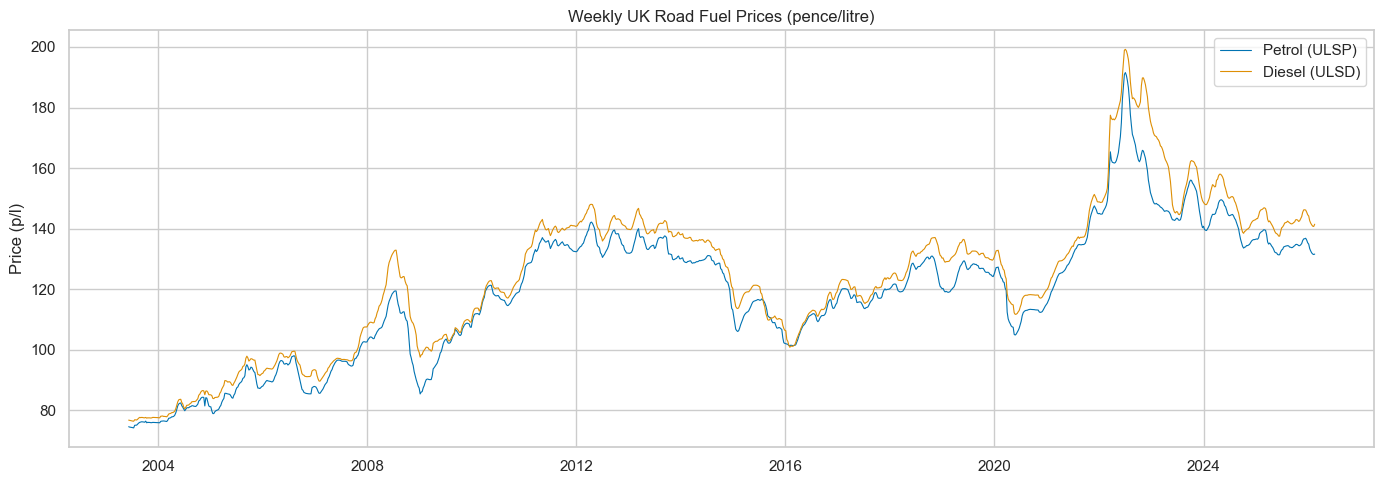

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fuel['date'], fuel['petrol_price'], label='Petrol (ULSP)', linewidth=0.8)
ax.plot(fuel['date'], fuel['diesel_price'], label='Diesel (ULSD)', linewidth=0.8)
ax.set_title('Weekly UK Road Fuel Prices (pence/litre)')
ax.set_ylabel('Price (p/l)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Road Freight Transport Price Index (SPPI)

In [22]:
# Parse the SPPI series
sppi_raw = pd.read_csv(DATA + 'series-210226.csv', header=None)
print("First 15 rows:")
for i in range(min(15, len(sppi_raw))):
    print(f"  {i}: {sppi_raw.iloc[i].dropna().tolist()}")

First 15 rows:
  0: ['Title', 'SPPI INDEX OUTPUT DOMESTIC - H4941 Freight transport services by road 2015=100']
  1: ['CDID', 'HQEB']
  2: ['Source dataset ID', 'SPPI']
  3: ['PreUnit']
  4: ['Unit']
  5: ['Release date', '22-10-2025']
  6: ['Next release', '21 January 2026']
  7: ['Important notes']
  8: ['1996', '66.7']
  9: ['1997', '70.1']
  10: ['1998', '69.8']
  11: ['1999', '71.4']
  12: ['2000', '74.8']
  13: ['2001', '76.6']
  14: ['2002', '77.3']


SPPI shape: (119, 3)
Date range: 1996-01-01 to 2025-07-01
Duplicate dates: 0


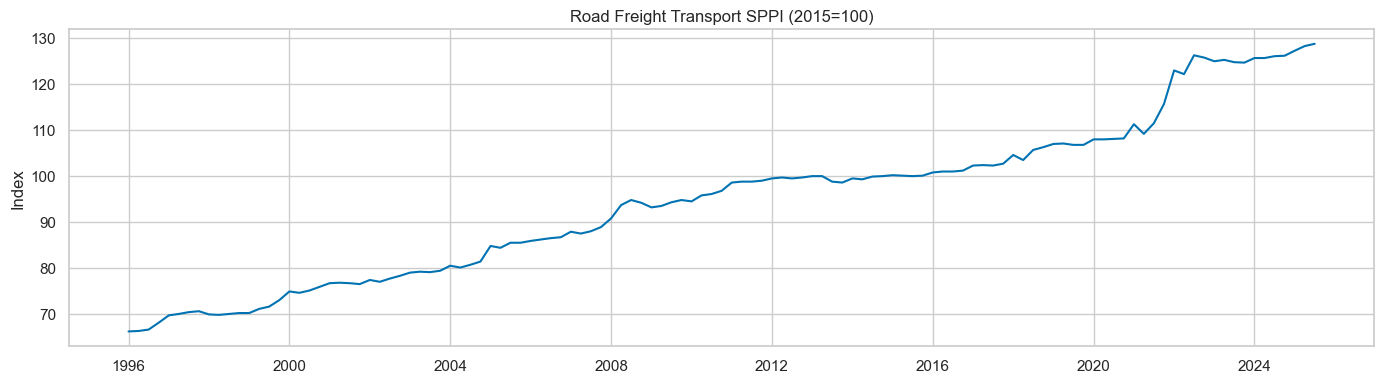

In [23]:
# Parse SPPI data: skip metadata, extract year/quarter and value
sppi_raw = pd.read_csv(DATA + 'series-210226.csv', header=None)

data_rows = []
for i in range(len(sppi_raw)):
    val = str(sppi_raw.iloc[i, 0]).strip()
    if val[:4].isdigit() and len(val) <= 10:
        data_rows.append(i)

if data_rows:
    start = data_rows[0]
    sppi = sppi_raw.iloc[start:].copy()
    sppi.columns = range(sppi.shape[1])
    sppi = sppi[[0, 1]].rename(columns={0: 'period', 1: 'value'})
    sppi['value'] = pd.to_numeric(sppi['value'], errors='coerce')
    sppi = sppi.dropna(subset=['value']).reset_index(drop=True)
    
    def parse_period(p):
        p = str(p).strip()
        if 'Q' in p:
            parts = p.split()
            year = int(parts[0])
            q = int(parts[1].replace('Q', ''))
            month = (q - 1) * 3 + 1
            return pd.Timestamp(year=year, month=month, day=1)
        else:
            return pd.Timestamp(year=int(p), month=1, day=1)  # Annual -> Jan 1
    
    sppi['date'] = sppi['period'].apply(parse_period)
    # Drop duplicates keeping the more granular (quarterly) value
    sppi = sppi.sort_values('date').drop_duplicates(subset='date', keep='last').reset_index(drop=True)
    
    print(f"SPPI shape: {sppi.shape}")
    print(f"Date range: {sppi['date'].min().date()} to {sppi['date'].max().date()}")
    print(f"Duplicate dates: {sppi['date'].duplicated().sum()}")
    
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(sppi['date'], sppi['value'])
    ax.set_title('Road Freight Transport SPPI (2015=100)')
    ax.set_ylabel('Index')
    plt.tight_layout()
    plt.show()
    
    sppi.describe()

---
## 6. Consumer Price Inflation (CPI/CPIH)

In [24]:
# Read the contents sheet
cpi_contents = pd.read_excel(
    DATA + 'consumerpriceinflationdetailedreferencetables.xlsx',
    sheet_name='Contents'
)
cpi_contents

,"NOTE: Since publication of the April 2025 figures on 21 May, an error has been discovered in the licensed vehicles data provided by the Department for Transport",Unnamed: 1
0,and used to calculate the April Vehicle Excise...,NaN
1,This had the effect of overstating the headlin...,NaN
2,and Retail Prices Index (RPI) 12-month rates f...,NaN
3,In line with the established revisions policie...,NaN
4,Impact of vehicle excise duty on headline UK c...,NaN
5,NaN,NaN
6,Consumer Price Inflation,NaN
7,Publication date: 18 February 2026,NaN
8,Next publication date: 25 March 2026,NaN
9,To access data tables select the table heading...,NaN


In [25]:
# Read Table 37 - CPIH detailed indices 1988-2026 (long time series)
cpi_t37_raw = pd.read_excel(
    DATA + 'consumerpriceinflationdetailedreferencetables.xlsx',
    sheet_name='Table 37',
    header=None
)
print(f"Table 37 shape: {cpi_t37_raw.shape}")
for i in range(10):
    non_null = cpi_t37_raw.iloc[i].dropna()
    print(f"Row {i} ({len(non_null)} non-null): {non_null.values[:5]}")

Table 37 shape: (497, 181)
Row 0 (2 non-null): ['Back to Contents'
 'THE FIGURES IN THIS TABLE ARE NOT accredited official statistics AND SHOULD BE USED FOR ANALYTICAL PURPOSES ONLY']
Row 1 (0 non-null): []
Row 2 (2 non-null): ['Table 37' 'CPIH: Detailed indices to 3 dp: 1988 to 2026 1,2,3,4,5']
Row 3 (0 non-null): []
Row 4 (179 non-null): ['aggregate number' 0 1 1.1 '01.1.1']
Row 5 (179 non-null): ['cdid' 'L522  ' 'L523  ' 'L52H  ' 'L52I  ']
Row 6 (180 non-null): ['index date   ' 'name' 'CPIH ALL ITEMS'
 'FOOD AND NON-ALCOHOLIC BEVERAGES' 'FOOD']
Row 7 (180 non-null): [198801 datetime.datetime(1988, 1, 1, 0, 0) 46.851 47.901 48.244]
Row 8 (180 non-null): [198802 datetime.datetime(1988, 2, 1, 0, 0) 46.998 48.174 48.501]
Row 9 (180 non-null): [198803 datetime.datetime(1988, 3, 1, 0, 0) 47.202 48.324 48.643]


In [26]:
# Extract CPIH time series for key food categories
t37 = cpi_t37_raw.copy()

# Find date row (row with many Timestamps)
date_row_idx = None
for i in range(10):
    ts_count = sum(1 for v in t37.iloc[i] if isinstance(v, pd.Timestamp))
    if ts_count > 20:
        date_row_idx = i
        break

if date_row_idx is None:
    for i in range(10):
        str_dates = sum(1 for v in t37.iloc[i]
                        if pd.notna(v) and len(str(v)) > 5 and str(v)[:4].isdigit())
        if str_dates > 20:
            date_row_idx = i
            break

print(f"Date row: {date_row_idx}")

if date_row_idx is not None:
    dates = []
    date_col_indices = []
    for col_idx in range(t37.shape[1]):
        val = t37.iloc[date_row_idx, col_idx]
        if pd.notna(val):
            try:
                d = pd.to_datetime(val)
                dates.append(d)
                date_col_indices.append(col_idx)
            except:
                pass
    print(f"Parsed {len(dates)} dates: {dates[0]} to {dates[-1]}")

    food_cats = {
        'Food and non-alcoholic beverages': None,
        'Fruit': None,
        'Vegetables': None,
    }
    
    for i in range(date_row_idx + 1, len(t37)):
        label_parts = [str(v).strip() for v in t37.iloc[i, :4] if pd.notna(v)]
        label = ' '.join(label_parts)
        for cat in food_cats:
            if cat.lower() in label.lower() and food_cats[cat] is None:
                values = []
                for col_idx in date_col_indices:
                    v = t37.iloc[i, col_idx]
                    try:
                        values.append(float(v))
                    except:
                        values.append(np.nan)
                food_cats[cat] = pd.Series(values, index=dates, name=cat)
                print(f"  Extracted '{cat}' from row {i}: {len(values)} values")
                break

    fig, ax = plt.subplots(figsize=(14, 5))
    for cat, series in food_cats.items():
        if series is not None:
            ax.plot(series.index, series.values, label=cat)
    ax.set_title('CPIH Indices -- Food Categories (2015=100)')
    ax.set_ylabel('Index')
    ax.legend()
    plt.tight_layout()
    plt.show()

Date row: None


In [27]:
# Find all food-related rows in Table 37
food_keywords = ['food', 'fruit', 'vegetable', 'meat', 'bread', 'milk', 'sugar']

food_rows = []
for i in range(len(t37)):
    row_text = ' '.join([str(v).lower() for v in t37.iloc[i, :4] if pd.notna(v)])
    if any(kw in row_text for kw in food_keywords):
        food_rows.append(i)
        print(f"Row {i}: {[str(v)[:40] for v in t37.iloc[i, :4] if pd.notna(v)]}")

print(f"\nFound {len(food_rows)} food-related rows")

Row 6: ['index date   ', 'name', 'CPIH ALL ITEMS', 'FOOD AND NON-ALCOHOLIC BEVERAGES']

Found 1 food-related rows


---
## 7. Data Alignment & Overlap Analysis

All datasets need to be aligned to a common timeline for modeling. Let's check temporal overlap.

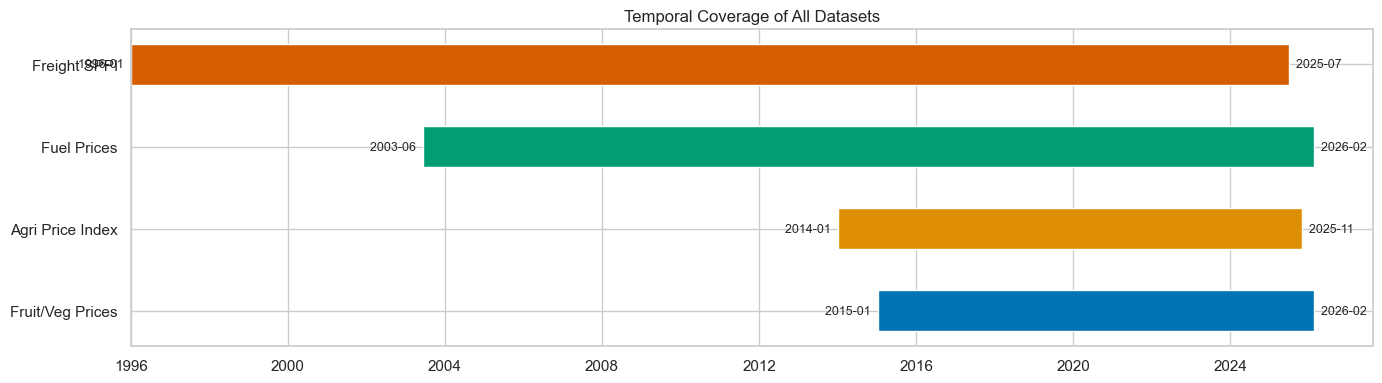


Common overlap period:
  2015-01-09 to 2025-07-01


In [28]:
# Summarize date ranges of all datasets
date_ranges = {
    'Fruit/Veg Prices': (fv['date'].min(), fv['date'].max(), 'Weekly'),
    'Agri Price Index': (api['date'].min(), api['date'].max(), 'Monthly'),
    'Fuel Prices': (fuel['date'].min(), fuel['date'].max(), 'Weekly'),
    'Freight SPPI': (sppi['date'].min(), sppi['date'].max(), 'Quarterly'),
}

fig, ax = plt.subplots(figsize=(14, 4))
colors = sns.color_palette('colorblind', len(date_ranges))

for i, (name, (start, end, freq)) in enumerate(date_ranges.items()):
    ax.barh(i, (end - start).days, left=start, height=0.5, color=colors[i],
            label=f'{name} ({freq})')
    ax.text(end, i, f'  {end.strftime("%Y-%m")}', va='center', fontsize=9)
    ax.text(start, i, f'{start.strftime("%Y-%m")}  ', va='center', ha='right', fontsize=9)

ax.set_yticks(range(len(date_ranges)))
ax.set_yticklabels(date_ranges.keys())
ax.set_title('Temporal Coverage of All Datasets')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print("\nCommon overlap period:")
all_starts = [v[0] for v in date_ranges.values()]
all_ends = [v[1] for v in date_ranges.values()]
overlap_start = max(all_starts)
overlap_end = min(all_ends)
print(f"  {overlap_start.date()} to {overlap_end.date()}")

In [29]:
# Resample all datasets to weekly frequency for alignment

# 1. Fruit/Veg - already weekly, pick key commodities for correlation
key_items = ['Strawberries', 'Braeburn', 'Conference', 'Cucumbers',
             'Iceberg', 'Carrots', 'Round']

fv_weekly = fv[fv['variety'].isin(key_items)].pivot_table(
    index='date', columns='variety', values='price'
).resample('W').mean()

# 2. API - monthly -> weekly via forward-fill
api_pivot = api.pivot_table(index='date', columns='category', values='index')
api_weekly = api_pivot.resample('W').ffill()

# 3. Fuel - already weekly
fuel_weekly = fuel.set_index('date')[['petrol_price', 'diesel_price']].resample('W').mean()

# 4. SPPI - quarterly -> weekly via forward-fill
sppi_weekly = sppi.set_index('date')[['value']].rename(columns={'value': 'freight_sppi'})
sppi_weekly = sppi_weekly.resample('W').ffill()

# Combine all
api_feature_cols = ['fresh_vegetables', 'fresh_fruit', 'fertilisers_and_soil_improvers',
                    'energy_and_lubricants', 'seeds_input']
api_feature_cols = [c for c in api_feature_cols if c in api_weekly.columns]

combined = fv_weekly.join(api_weekly[api_feature_cols], how='outer')
combined = combined.join(fuel_weekly, how='outer')
combined = combined.join(sppi_weekly, how='outer')
combined = combined.ffill().dropna(how='all')

# Filter to overlap period
combined = combined.loc[overlap_start:overlap_end]

print(f"Combined weekly dataset: {combined.shape}")
print(f"Date range: {combined.index.min().date()} to {combined.index.max().date()}")
print(f"\nNull counts:")
print(combined.isnull().sum())
combined.head()

Combined weekly dataset: (547, 11)
Date range: 2015-01-11 to 2025-06-29

Null counts:
Braeburn                          147
Conference                        147
Round                             147
fresh_vegetables                    0
fresh_fruit                         0
fertilisers_and_soil_improvers      0
energy_and_lubricants               0
seeds_input                         0
petrol_price                        0
diesel_price                        0
freight_sppi                        0
dtype: int64


,Braeburn,Conference,Round,fresh_vegetables,fresh_fruit,fertilisers_and_soil_improvers,energy_and_lubricants,seeds_input,petrol_price,diesel_price,freight_sppi
date,,,,,,,,,,,
2015-01-11,NaN,NaN,NaN,72.977881,56.097455,119.925622,91.688446,88.761514,111.06,117.93,100.1
2015-01-18,NaN,NaN,NaN,72.977881,56.097455,119.925622,91.688446,88.761514,108.87,116.22,100.1
2015-01-25,NaN,NaN,NaN,72.977881,56.097455,119.925622,91.688446,88.761514,106.83,114.33,100.1
2015-02-01,NaN,NaN,NaN,74.438698,54.264844,119.966033,90.558781,88.794969,106.32,113.76,100.1
2015-02-08,NaN,NaN,NaN,74.438698,54.264844,119.966033,90.558781,88.794969,106.04,113.61,100.1


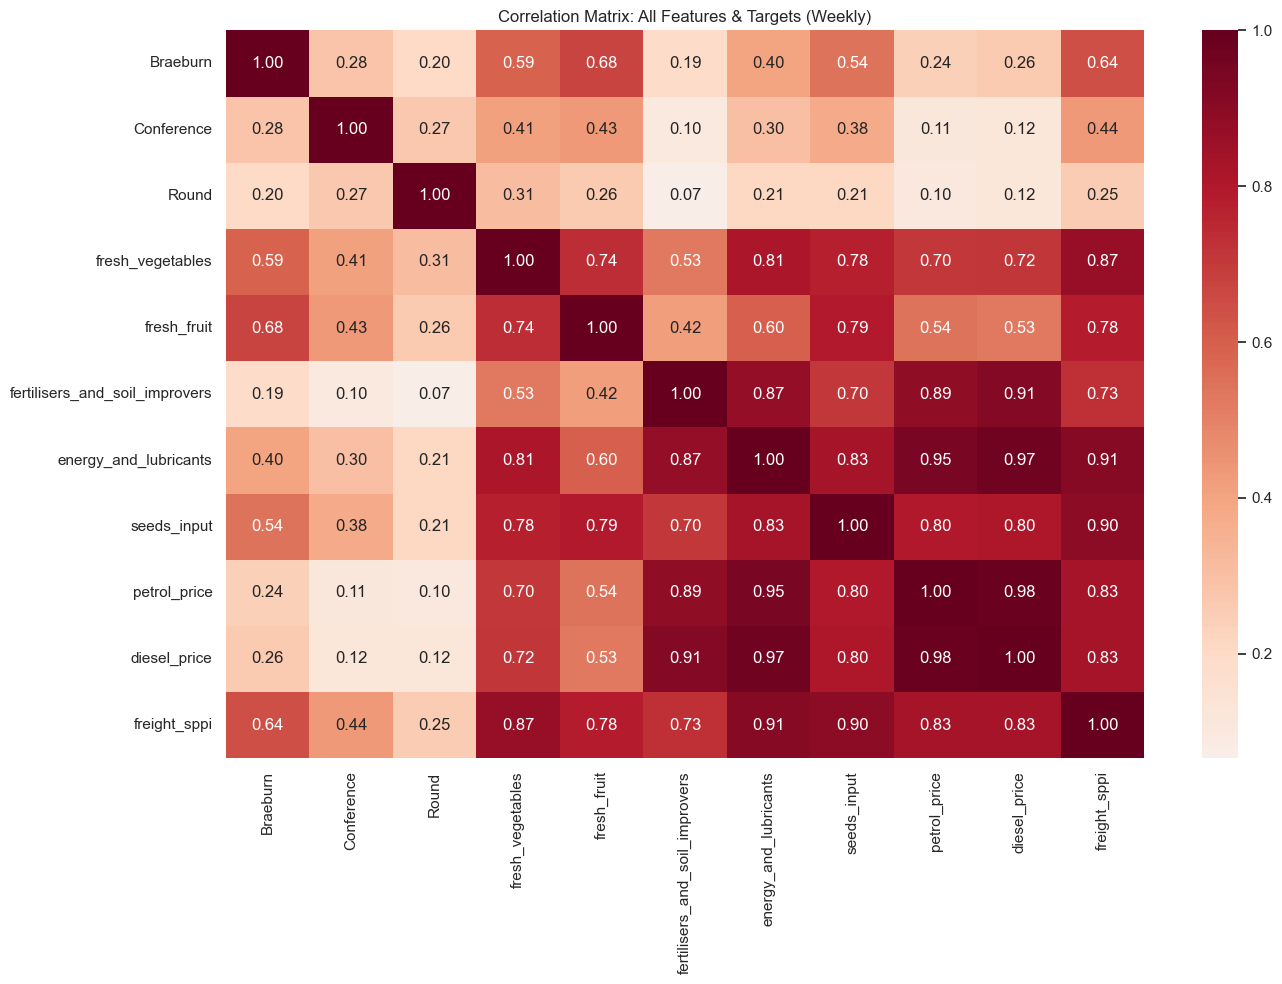

In [30]:
# Correlation heatmap between features and target variables
corr = combined.corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title('Correlation Matrix: All Features & Targets (Weekly)')
plt.tight_layout()
plt.show()

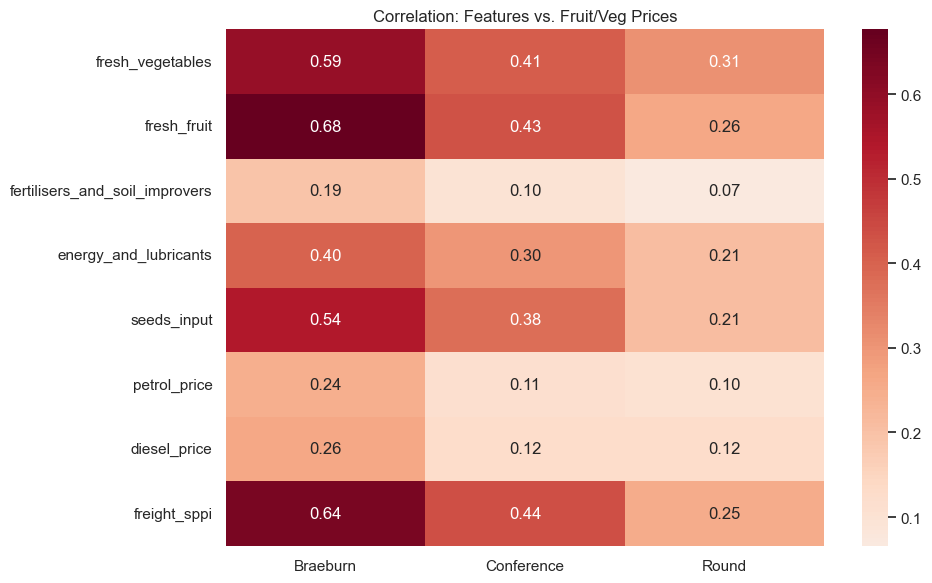

In [31]:
# Focus on correlations with fruit/veg prices
target_cols = [c for c in key_items if c in combined.columns]
feature_cols = [c for c in combined.columns if c not in key_items]

if target_cols and feature_cols:
    target_corr = combined[feature_cols + target_cols].corr().loc[feature_cols, target_cols]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(target_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
    ax.set_title('Correlation: Features vs. Fruit/Veg Prices')
    plt.tight_layout()
    plt.show()

---
## 8. Key Observations & Next Steps

### Observations
1. **Target variable**: Weekly wholesale fruit and vegetable prices from DEFRA (72 commodities, 2015-2026)
2. **Strong seasonality**: Many items (especially berries, soft fruit) show pronounced seasonal patterns -- prices spike in off-season when UK supply is low
3. **Missing data**: Seasonal crops (e.g., gooseberries, forced rhubarb) have >50% missing weeks -- they are simply not available year-round
4. **Input cost signals**: Fertiliser prices, energy costs, and transport costs all show significant variation and are plausible drivers of produce prices
5. **Temporal alignment**: The common overlap period across all datasets spans roughly 2017-2025, giving ~8 years of aligned data
6. **Frequency mismatch**: Target is weekly, features range from weekly (fuel) to quarterly (SPPI) -- forward-fill used for alignment

### Next Steps for Modeling
- **Feature engineering**: Create lagged features (1-4 week lags), rolling averages, year-over-year changes, seasonal indicators (week-of-year, month)
- **Handle seasonality**: Consider separate models for seasonal vs. year-round crops
- **Model candidates**: Time-series models (ARIMA/SARIMAX), gradient boosting (XGBoost/LightGBM), LSTM/temporal neural nets
- **Evaluation**: Time-based train/test split (e.g., train through 2024, test on 2025)